# IT Operations Intelligence
## Fase 6: Análisis Exploratorio de Datos (EDA)

**Objetivo:** Realizar un análisis detallado de las variables del dataset transformado para identificar patrones, relaciones y características relevantes para el modelado predictivo.

In [ ]:
import pandas as pd # Librería para manipulación y análisis de datos
import numpy as np # Librería para operaciones numéricas y matrices
import matplotlib.pyplot as plt # Librería para crear gráficos estáticos
import seaborn as sns # Librería para visualización estadística avanzada
import os # Módulo para interactuar con el sistema operativo (rutas, directorios)

plt.style.use("default")  # Configura el estilo visual por defecto de matplotlib

pd.set_option("display.max_columns", None)  # Muestra todas las columnas sin ocultar ninguna

ruta_graficos = "../reports/graphics"  # Define la ruta donde se guardarán los gráficos generados

os.makedirs(ruta_graficos, exist_ok=True)  # Crea el directorio de gráficos si no existe


In [ ]:
# Cargar el dataset transformado desde el archivo CSV procesado
df = pd.read_csv("../data/processed/incident_event_log_transformado.csv")  # Lee el CSV en un DataFrame de pandas


In [ ]:
# Visualizar las primeras filas del DataFrame para inspeccionar la estructura de los datos
df.head()  # Muestra las primeras 5 filas del dataset, permitiendo ver las columnas y tipos de datos


,number,incident_state,active,reassignment_count,reopen_count,sys_mod_count,made_sla,caller_id,opened_by,opened_at,sys_created_by,sys_created_at,sys_updated_by,sys_updated_at,contact_type,location,category,subcategory,u_symptom,cmdb_ci,impact,urgency,priority,assignment_group,assigned_to,knowledge,u_priority_confirmation,notify,problem_id,rfc,vendor,caused_by,closed_code,resolved_by,resolved_at,closed_at,open_hour,open_dayofweek,open_month,open_year,resolution_time_hours,priority_score,impact_score,urgency_score,criticality_score,criticality_level,problematic_ticket,made_sla_num
0,INC0000045,New,True,0,0,0,True,Caller 2403,Opened by 8,2016-02-29 01:16:00,Created by 6,2016-02-29 01:23:00,Updated by 21,2016-02-29 01:23:00,Phone,Location 143,Category 55,Subcategory 170,Symptom 72,?,2 - Medium,2 - Medium,3 - Moderate,Group 56,?,True,False,Do Not Notify,?,?,?,?,code 5,Resolved by 149,2016-02-29 11:29:00,2016-03-05 12:00:00,1,0,2,2016,10.216667,2,2,2,2.0,Medium,0,1
1,INC0000045,Resolved,True,0,0,2,True,Caller 2403,Opened by 8,2016-02-29 01:16:00,Created by 6,2016-02-29 01:23:00,Updated by 642,2016-02-29 08:53:00,Phone,Location 143,Category 55,Subcategory 170,Symptom 72,?,2 - Medium,2 - Medium,3 - Moderate,Group 56,?,True,False,Do Not Notify,?,?,?,?,code 5,Resolved by 149,2016-02-29 11:29:00,2016-03-05 12:00:00,1,0,2,2016,10.216667,2,2,2,2.0,Medium,0,1
2,INC0000045,Resolved,True,0,0,3,True,Caller 2403,Opened by 8,2016-02-29 01:16:00,Created by 6,2016-02-29 01:23:00,Updated by 804,2016-02-29 11:29:00,Phone,Location 143,Category 55,Subcategory 170,Symptom 72,?,2 - Medium,2 - Medium,3 - Moderate,Group 56,?,True,False,Do Not Notify,?,?,?,?,code 5,Resolved by 149,2016-02-29 11:29:00,2016-03-05 12:00:00,1,0,2,2016,10.216667,2,2,2,2.0,Medium,0,1
3,INC0000045,Closed,False,0,0,4,True,Caller 2403,Opened by 8,2016-02-29 01:16:00,Created by 6,2016-02-29 01:23:00,Updated by 908,2016-03-05 12:00:00,Phone,Location 143,Category 55,Subcategory 170,Symptom 72,?,2 - Medium,2 - Medium,3 - Moderate,Group 56,?,True,False,Do Not Notify,?,?,?,?,code 5,Resolved by 149,2016-02-29 11:29:00,2016-03-05 12:00:00,1,0,2,2016,10.216667,2,2,2,2.0,Medium,0,1
4,INC0000047,New,True,0,0,0,True,Caller 2403,Opened by 397,2016-02-29 04:40:00,Created by 171,2016-02-29 04:57:00,Updated by 746,2016-02-29 04:57:00,Phone,Location 165,Category 40,Subcategory 215,Symptom 471,?,2 - Medium,2 - Medium,3 - Moderate,Group 70,Resolver 89,True,False,Do Not Notify,?,?,?,?,code 5,Resolved by 81,2016-03-01 09:52:00,2016-03-06 10:00:00,4,0,2,2016,29.200000,2,2,2,2.0,Medium,0,1


##### Análisis: Vista preliminar del dataset
Se observan 48 columnas con datos de incidentes IT. Cada fila representa un cambio de estado en el ciclo de vida de un ticket. Aparecen variables temporales (`opened_at`, `resolved_at`), categóricas (`category`, `priority`, `impact`) y numéricas (`reassignment_count`, `resolution_time_hours`). La columna `made_sla` (booleana) será nuestra variable objetivo para predecir cumplimiento de SLA.


In [ ]:
# Obtener la dimensión del dataset (filas, columnas)
df.shape  # Devuelve una tupla con el número de filas (141,712) y columnas (48)


(141712, 48)

##### Análisis: Dimensiones del dataset
El dataset contiene 141,712 registros y 48 columnas. Esto representa un volumen significativo de datos para entrenar modelos de machine learning, aunque requerirá preprocesamiento para manejar valores nulos y codificar variables categóricas.


In [ ]:
# Obtener información detallada del DataFrame: tipos de datos, valores no nulos y uso de memoria
df.info()  # Muestra el resumen completo del DataFrame, incluyendo dtype de cada columna y conteo de no-nulos


<class 'pandas.DataFrame'>
RangeIndex: 141712 entries, 0 to 141711
Data columns (total 48 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   number                   141712 non-null  str    
 1   incident_state           141712 non-null  str    
 2   active                   141712 non-null  bool   
 3   reassignment_count       141712 non-null  int64  
 4   reopen_count             141712 non-null  int64  
 5   sys_mod_count            141712 non-null  int64  
 6   made_sla                 141712 non-null  bool   
 7   caller_id                141712 non-null  str    
 8   opened_by                141712 non-null  str    
 9   opened_at                141712 non-null  str    
 10  sys_created_by           141712 non-null  str    
 11  sys_created_at           88636 non-null   str    
 12  sys_updated_by           141712 non-null  str    
 13  sys_updated_at           141712 non-null  str    
 14  contact_type   

##### Análisis: Tipos de datos y valores nulos
El dataset tiene 30 columnas de tipo `str` (categóricas), 12 `int64`, 2 `float64`, y 4 `bool`. Se identifican valores nulos en `sys_created_at`, `resolved_at` y `resolution_time_hours` (~3,141 registros), lo que corresponde a tickets aún no resueltos. No hay nulos en la variable objetivo `made_sla_num`.


### Análisis Univariante

In [6]:
# Mostrar encabezado del análisis de la variable objetivo
print("Distribución de made_sla (objetivo):")

# Contar tickets que cumplen (1) y no cumplen (0) SLA
print(df["made_sla_num"].value_counts())

# Línea en blanco para separar secciones
print()

# Mostrar encabezado de porcentajes
print("Porcentaje:")

# Calcular y mostrar porcentajes con 2 decimales
print(round(df["made_sla_num"].value_counts(normalize=True) * 100, 2))


Distribución de made_sla (objetivo):
made_sla_num
1    132497
0      9215
Name: count, dtype: int64

Porcentaje:
made_sla_num
1    93.5
0     6.5
Name: proportion, dtype: float64


##### Análisis: Distribución de la variable objetivo
Existe un fuerte desbalanceo: el 93.5% de los tickets cumplen SLA (made_sla_num=1) y solo el 6.5% incumplen (made_sla_num=0). Esto es crítico para el modelado, ya que requerirá técnicas de balanceo (SMOTE, pesos de clase, etc.) para evitar que el modelo prediga siempre la clase mayoritaria.


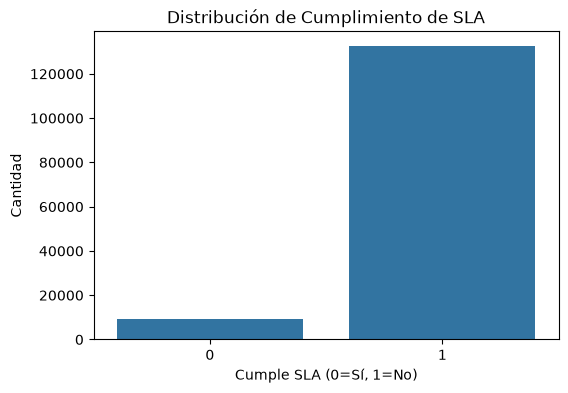

In [7]:
# Definir el tamaño de la figura (6 pulgadas ancho, 4 alto)
plt.figure(figsize=(6, 4))

# Crear un gráfico de conteo de tickets por valor de made_sla_num
sns.countplot(data=df, x="made_sla_num")

# Establecer el título del gráfico
plt.title("Distribución de Cumplimiento de SLA")

# Etiqueta del eje X
plt.xlabel("Cumple SLA (0=Sí, 1=No)")

# Etiqueta del eje Y (número de tickets)
plt.ylabel("Cantidad")

# Guardar la figura en formato PNG a 300 dpi
plt.savefig(f"{ruta_graficos}/Nb03_01_distribucion_sla.png", dpi=300, bbox_inches="tight")

# Mostrar el gráfico en pantalla
plt.show()


##### Análisis: Distribución de cumplimiento de SLA
El gráfico de barras confirma el fuerte desbalanceo: los tickets que incumplen SLA (made_sla_num=0) son una minoría frente a los que cumplen. Esta distribución asimétrica deberá ser abordada con técnicas de balanceo durante la fase de modelado para evitar sesgos hacia la clase mayoritaria.


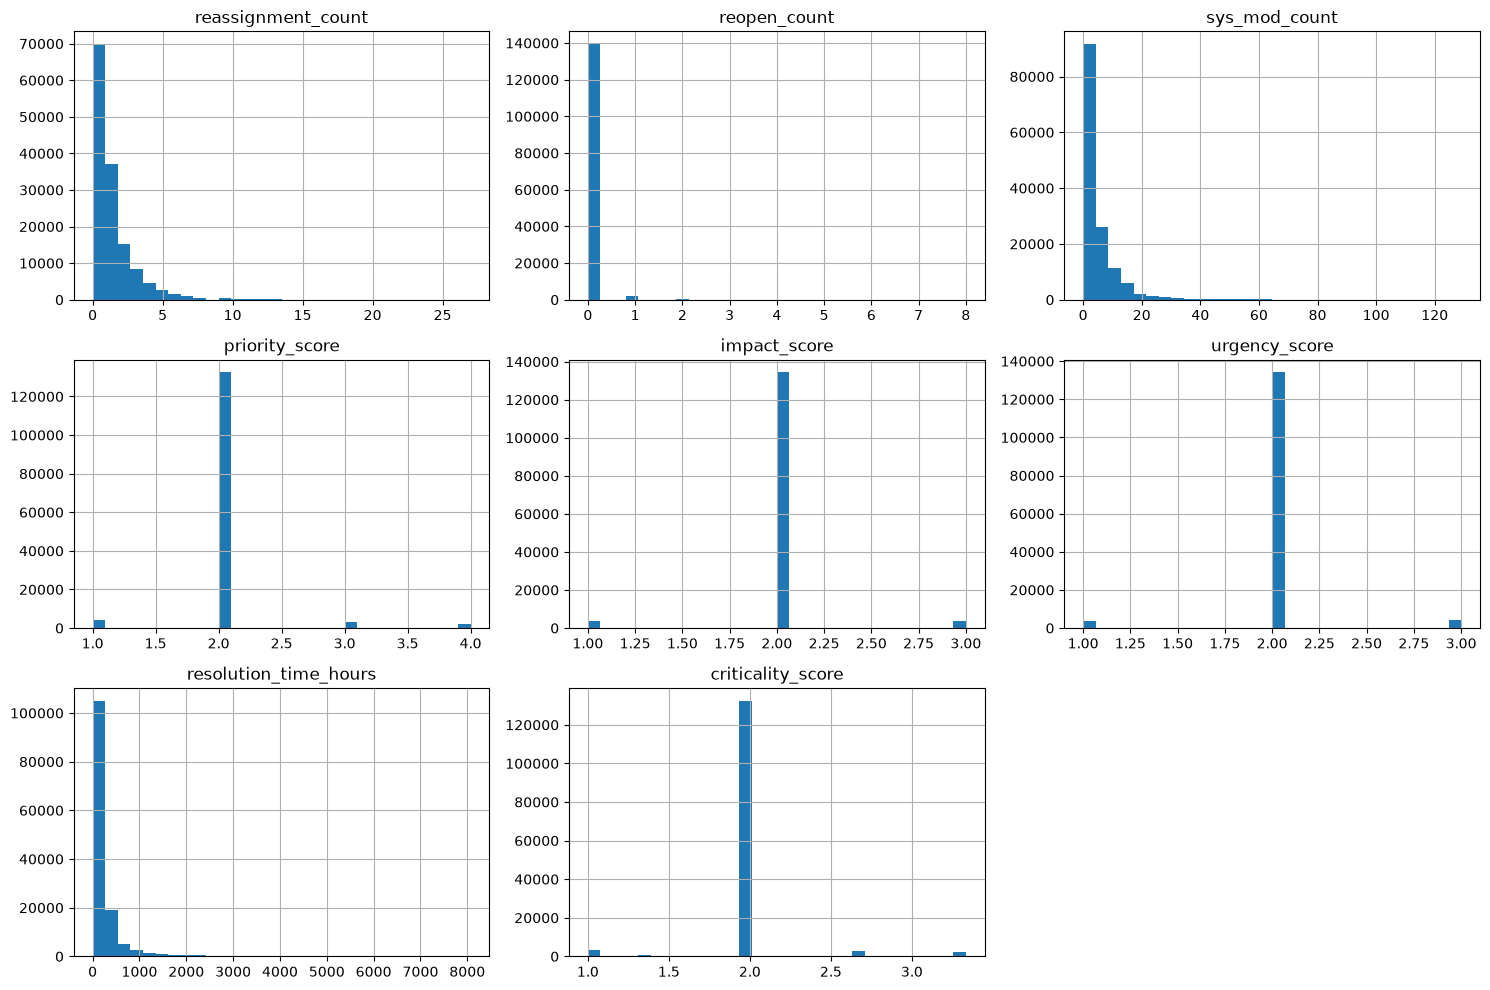

In [8]:
# Definir la lista de variables numéricas principales para analizar
num_cols = ["reassignment_count", "reopen_count", "sys_mod_count",
            "priority_score", "impact_score", "urgency_score",
            "resolution_time_hours", "criticality_score"]

# Filtrar solo las columnas que existen en el DataFrame
cols_existentes = [c for c in num_cols if c in df.columns]

# Generar histogramas de las variables seleccionadas con 30 bins cada una
df[cols_existentes].hist(figsize=(15, 10), bins=30)

# Ajustar el diseño para evitar superposiciones entre subgráficos
plt.tight_layout()

# Guardar la figura en PNG a 300 dpi
plt.savefig(f"{ruta_graficos}/Nb03_02_distribuciones_clave.png", dpi=300, bbox_inches="tight")

# Mostrar los histogramas en pantalla
plt.show()


##### Análisis: Distribuciones de variables numéricas clave
Los histogramas revelan distribuciones asimétricas: `reassignment_count` y `reopen_count` tienen valores mayoritariamente bajos, indicando que la mayoría de tickets no requieren reasignaciones ni reaperturas. `resolution_time_hours` muestra una cola larga con tickets que toman muchas horas en resolverse. `criticality_score` y `priority_score` presentan distribuciones concentradas en valores medios, sugiriendo que la mayoría de tickets son de criticidad moderada.


### Análisis Bivariante

In [9]:
# Calcular la correlación de todas las variables numéricas con made_sla_num
correlaciones = df.select_dtypes(include=np.number).corr()["made_sla_num"].sort_values(ascending=False)

# Mostrar encabezado de correlaciones
print("Correlación con made_sla_num:")

# Mostrar los valores de correlación ordenados de mayor a menor
print(correlaciones)


Correlación con made_sla_num:
made_sla_num             1.000000
open_month               0.073351
open_dayofweek           0.008590
open_year                0.002592
open_hour               -0.012541
reopen_count            -0.015880
impact_score            -0.041607
urgency_score           -0.047101
criticality_score       -0.049124
priority_score          -0.050001
resolution_time_hours   -0.073415
problematic_ticket      -0.077016
reassignment_count      -0.089037
sys_mod_count           -0.241942
Name: made_sla_num, dtype: float64


##### Análisis: Correlaciones con la variable objetivo
Las correlaciones más fuertes con `made_sla_num` son negativas: `sys_mod_count (-0.24)`, `reassignment_count (-0.09)`, y `resolution_time_hours (-0.07)`. Esto sugiere que a mayor número de modificaciones, reasignaciones o tiempo de resolución, menor es la probabilidad de cumplir SLA. Las variables temporales (`open_hour`, `open_month`) tienen correlaciones muy débiles.


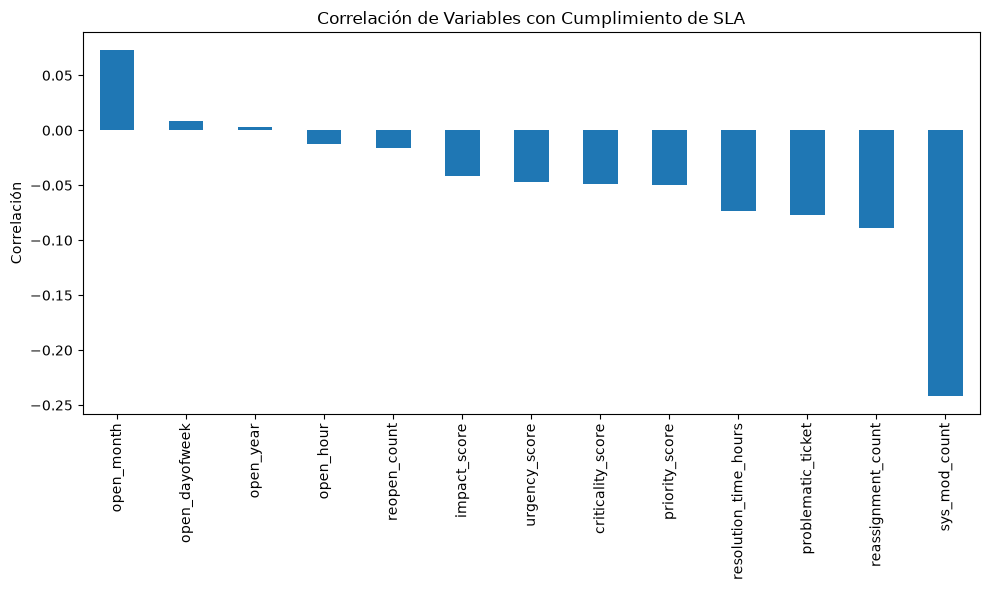

In [10]:
# Definir el tamaño de la figura (10 pulgadas ancho, 6 alto)
plt.figure(figsize=(10, 6))

# Crear gráfico de barras con las correlaciones excluyendo la variable objetivo
correlaciones.drop("made_sla_num").plot(kind="bar")

# Establecer el título del gráfico
plt.title("Correlación de Variables con Cumplimiento de SLA")

# Etiqueta del eje Y
plt.ylabel("Correlación")

# Ajustar el diseño para evitar superposiciones
plt.tight_layout()

# Guardar la figura en formato PNG a 300 dpi
plt.savefig(f"{ruta_graficos}/Nb03_03_correlacion_con_sla.png", dpi=300, bbox_inches="tight")

# Mostrar el gráfico en pantalla
plt.show()


##### Análisis: Correlación de variables con cumplimiento de SLA
El gráfico de barras confirma que `sys_mod_count` tiene la correlación negativa más fuerte con el cumplimiento de SLA, seguida de `reassignment_count` y `problematic_ticket`. Las variables `open_hour`, `open_dayofweek` y `open_year` tienen correlaciones cercanas a cero, indicando baja relación lineal con el SLA. Esto sugiere que características operativas del ticket (modificaciones, reasignaciones) son más predictivas que las temporales.


=== Prioridad vs SLA ===
made_sla      False   True 
priority                   
1 - Critical    265    1993
2 - High        406    2566
3 - Moderate   8419  124033
4 - Low         125    3905


<Figure size 800x500 with 0 Axes>

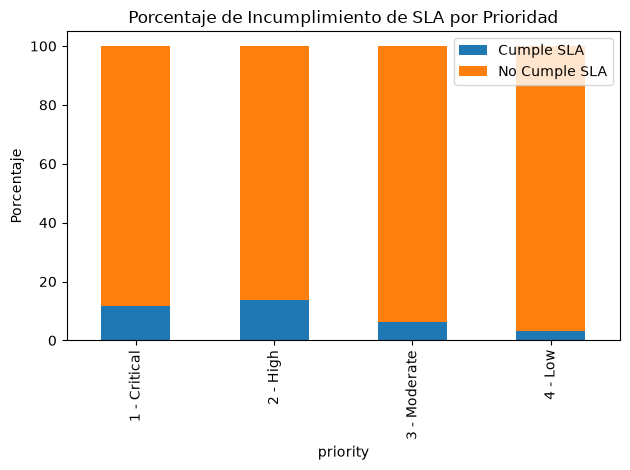

In [11]:
# Verificar que la columna priority exista en el DataFrame
if "priority" in df.columns:

    # Mostrar encabezado del análisis
    print("=== Prioridad vs SLA ===")

    # Mostrar tabla cruzada de prioridad vs SLA
    print(pd.crosstab(df["priority"], df["made_sla"]))

    # Crear figura para el gráfico
    plt.figure(figsize=(8, 5))

    # Calcular porcentajes por fila para comparar proporciones
    ct = pd.crosstab(df["priority"], df["made_sla"], normalize="index") * 100

    # Crear gráfico de barras apiladas
    ct.plot(kind="bar", stacked=True)

    # Establecer título del gráfico
    plt.title("Porcentaje de Incumplimiento de SLA por Prioridad")

    # Etiqueta del eje Y
    plt.ylabel("Porcentaje")

    # Mostrar leyenda con etiquetas
    plt.legend(["Cumple SLA", "No Cumple SLA"])

    # Ajustar diseño
    plt.tight_layout()

    # Guardar figura
    plt.savefig(f"{ruta_graficos}/Nb03_04_prioridad_vs_sla.png", dpi=300, bbox_inches="tight")

    # Mostrar gráfico
    plt.show()


##### Análisis: Prioridad vs Cumplimiento de SLA
La tabla cruzada y el gráfico apilado muestran que los tickets de prioridad crítica (1 - Critical) tienen una notable proporción de incumplimiento de SLA. Sin embargo, en términos absolutos, la categoría "3 - Moderate" concentra la mayor cantidad de incumplimientos debido a su gran volumen. Esto indica que la prioridad es un factor relevante pero no determinante por sí solo.


=== Criticality Level vs SLA ===
made_sla           False   True 
criticality_level               
High                 671    4559
Low                  125    3905
Medium              8419  124033


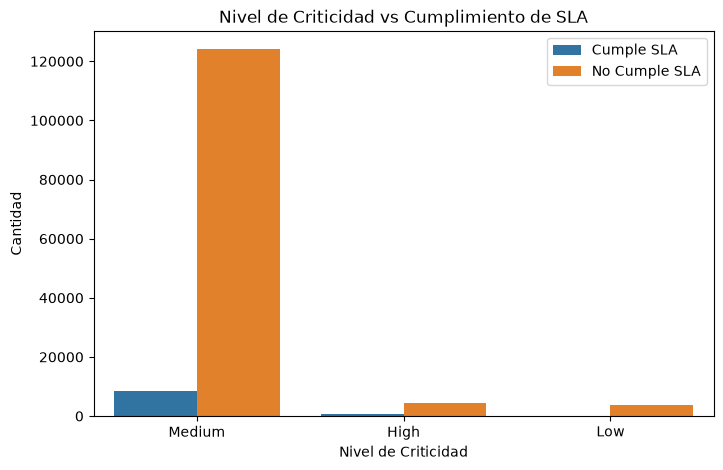

In [12]:
# Verificar que la columna criticality_level exista en el DataFrame
if "criticality_level" in df.columns:

    # Mostrar encabezado del análisis
    print("=== Criticality Level vs SLA ===")

    # Mostrar tabla cruzada de nivel de criticidad vs SLA
    print(pd.crosstab(df["criticality_level"], df["made_sla"]))

    # Crear figura para el gráfico
    plt.figure(figsize=(8, 5))

    # Crear gráfico de conteo agrupado por nivel de criticidad y SLA
    sns.countplot(data=df, x="criticality_level", hue="made_sla")

    # Establecer título
    plt.title("Nivel de Criticidad vs Cumplimiento de SLA")

    # Etiqueta del eje X
    plt.xlabel("Nivel de Criticidad")

    # Etiqueta del eje Y
    plt.ylabel("Cantidad")

    # Mostrar leyenda
    plt.legend(["Cumple SLA", "No Cumple SLA"])

    # Guardar figura
    plt.savefig(f"{ruta_graficos}/Nb03_05_criticidad_vs_sla.png", dpi=300, bbox_inches="tight")

    # Mostrar gráfico
    plt.show()


##### Análisis: Nivel de Criticidad vs Cumplimiento de SLA
El nivel de criticidad "High" presenta una mayor tasa relativa de incumplimiento comparado con "Medium" y "Low". La categoría "Medium" domina en volumen absoluto. Esto sugiere que los tickets de alta criticidad requieren atención especial para garantizar el cumplimiento del SLA.


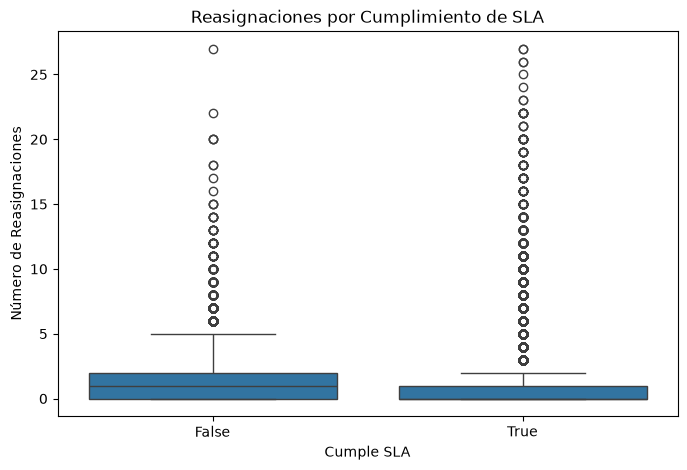

In [13]:
# Verificar que la columna reassignment_count exista en el DataFrame
if "reassignment_count" in df.columns:

    # Crear figura para el boxplot
    plt.figure(figsize=(8, 5))

    # Crear boxplot de reasignaciones agrupado por cumplimiento de SLA
    sns.boxplot(data=df, x="made_sla", y="reassignment_count")

    # Establecer título
    plt.title("Reasignaciones por Cumplimiento de SLA")

    # Etiqueta del eje X
    plt.xlabel("Cumple SLA")

    # Etiqueta del eje Y
    plt.ylabel("Número de Reasignaciones")

    # Guardar figura
    plt.savefig(f"{ruta_graficos}/Nb03_06_reasignaciones_vs_sla.png", dpi=300, bbox_inches="tight")

    # Mostrar gráfico
    plt.show()


##### Análisis: Reasignaciones por cumplimiento de SLA
El boxplot muestra que los tickets que no cumplen SLA (`made_sla=False`) tienden a tener un mayor número de reasignaciones, con una mediana más alta y más outliers. Las reasignaciones frecuentes pueden indicar problemas de enrutamiento o falta de especialización, lo que retrasa la resolución y afecta el SLA.


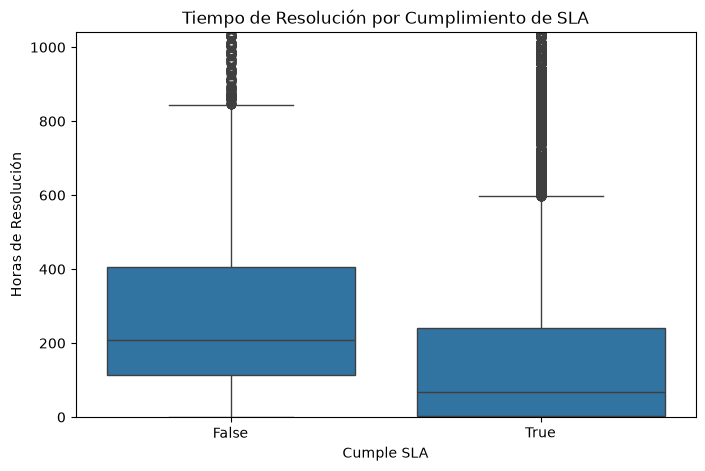

In [14]:
# Verificar que la columna resolution_time_hours exista en el DataFrame
if "resolution_time_hours" in df.columns:

    # Crear figura para el boxplot
    plt.figure(figsize=(8, 5))

    # Crear boxplot de tiempo de resolución agrupado por SLA
    sns.boxplot(data=df, x="made_sla", y="resolution_time_hours")

    # Establecer título
    plt.title("Tiempo de Resolución por Cumplimiento de SLA")

    # Etiqueta del eje X
    plt.xlabel("Cumple SLA")

    # Etiqueta del eje Y
    plt.ylabel("Horas de Resolución")

    # Limitar el eje Y al percentil 95 para mejor visualización
    plt.ylim(0, df["resolution_time_hours"].quantile(0.95))

    # Guardar figura
    plt.savefig(f"{ruta_graficos}/Nb03_07_tiempo_resolucion_vs_sla.png", dpi=300, bbox_inches="tight")

    # Mostrar gráfico
    plt.show()


##### Análisis: Tiempo de resolución por cumplimiento de SLA
Los tickets que no cumplen SLA presentan tiempos de resolución significativamente más altos, con una mediana superior y una dispersión mucho mayor. Esto era esperable, ya que el tiempo de resolución está directamente relacionado con el cumplimiento del SLA. Esta variable será clave para el modelo predictivo.


### Análisis de Correlación Avanzado

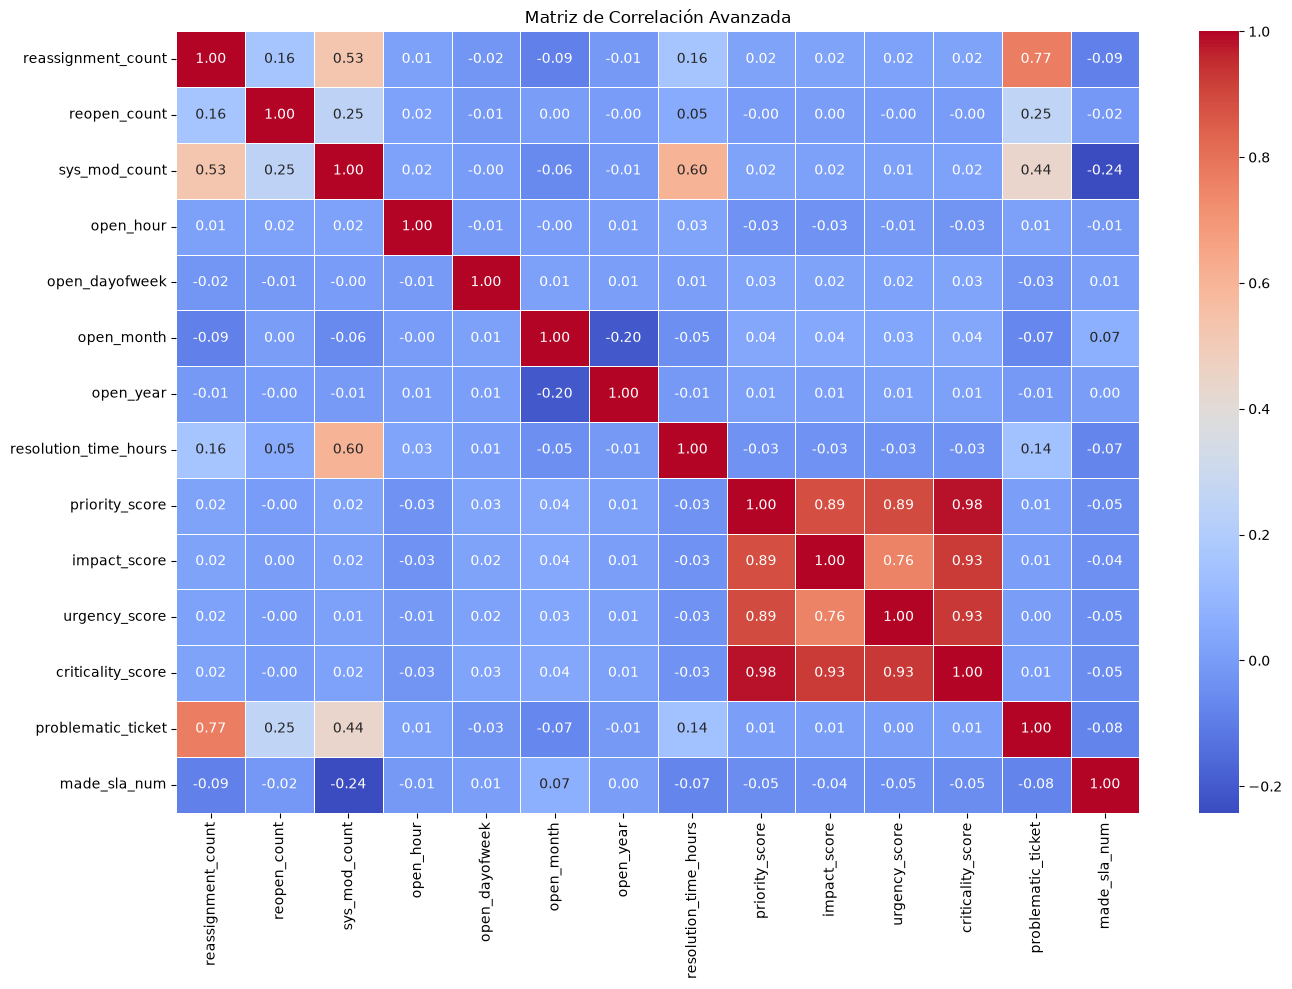

In [15]:
# Crear figura de tamaño grande para la matriz de correlación
plt.figure(figsize=(14, 10))

# Crear heatmap con anotaciones numéricas y escala de colores frío-cálido
sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5
)

# Establecer el título del heatmap
plt.title("Matriz de Correlación Avanzada")

# Ajustar el diseño para evitar recortes
plt.tight_layout()

# Guardar la figura en formato PNG a 300 dpi
plt.savefig(f"{ruta_graficos}/Nb03_08_matriz_correlacion_avanzada.png", dpi=300, bbox_inches="tight")

# Mostrar la matriz de correlación en pantalla
plt.show()


##### Análisis: Matriz de correlación avanzada
La matriz de correlación revela relaciones esperadas: `priority_score`, `impact_score` y `urgency_score` están altamente correlacionados entre sí (multicolinealidad). `criticality_score` se deriva de estos tres. `sys_mod_count` y `reassignment_count` tienen correlación positiva moderada. La variable objetivo `made_sla_num` muestra correlaciones débiles a moderadas con la mayoría de variables.


Top 10 categorías con mayor tasa de incumplimiento de SLA:
category
Category 12    1.0
Category 15    1.0
Category 14    1.0
Category 16    1.0
Category 2     1.0
Category 3     1.0
Category 27    1.0
Category 5     1.0
Category 50    1.0
Category 41    1.0
Name: made_sla_num, dtype: float64


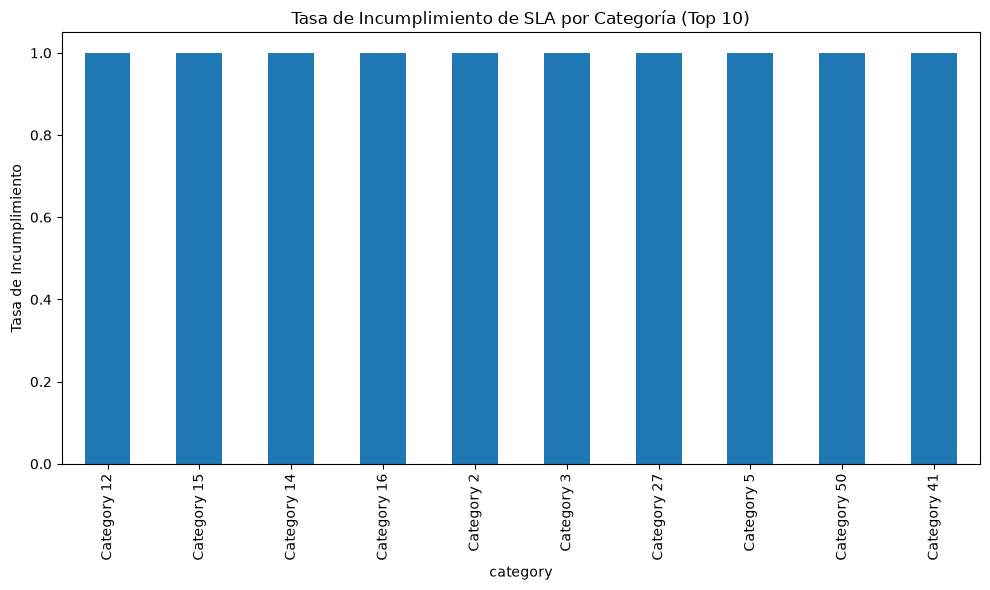

In [16]:
# Verificar que la columna category exista en el DataFrame
if "category" in df.columns:

    # Calcular tasa de incumplimiento promedio por categoría y tomar top 10
    sla_por_categoria = df.groupby("category")["made_sla_num"].mean().sort_values(ascending=False).head(10)

    # Mostrar encabezado del top 10
    print("Top 10 categorías con mayor tasa de incumplimiento de SLA:")

    # Mostrar las tasas de incumplimiento
    print(sla_por_categoria)

    # Crear figura para el gráfico de barras
    plt.figure(figsize=(10, 6))

    # Crear gráfico de barras con las tasas de incumplimiento
    sla_por_categoria.plot(kind="bar")

    # Establecer título
    plt.title("Tasa de Incumplimiento de SLA por Categoría (Top 10)")

    # Etiqueta del eje Y
    plt.ylabel("Tasa de Incumplimiento")

    # Ajustar diseño
    plt.tight_layout()

    # Guardar figura
    plt.savefig(f"{ruta_graficos}/Nb03_09_categorias_incumplimiento.png", dpi=300, bbox_inches="tight")

    # Mostrar gráfico
    plt.show()


##### Análisis: Categorías con mayor incumplimiento de SLA
Varias categorías (Category 12, 15, 14, 16, etc.) tienen una tasa de incumplimiento del 100%, aunque probablemente con pocos tickets cada una. Esto sugiere que ciertos tipos de incidentes son inherentemente más difíciles de resolver dentro del SLA. Se recomienda investigar estas categorías para posibles mejoras en los procesos de resolución.


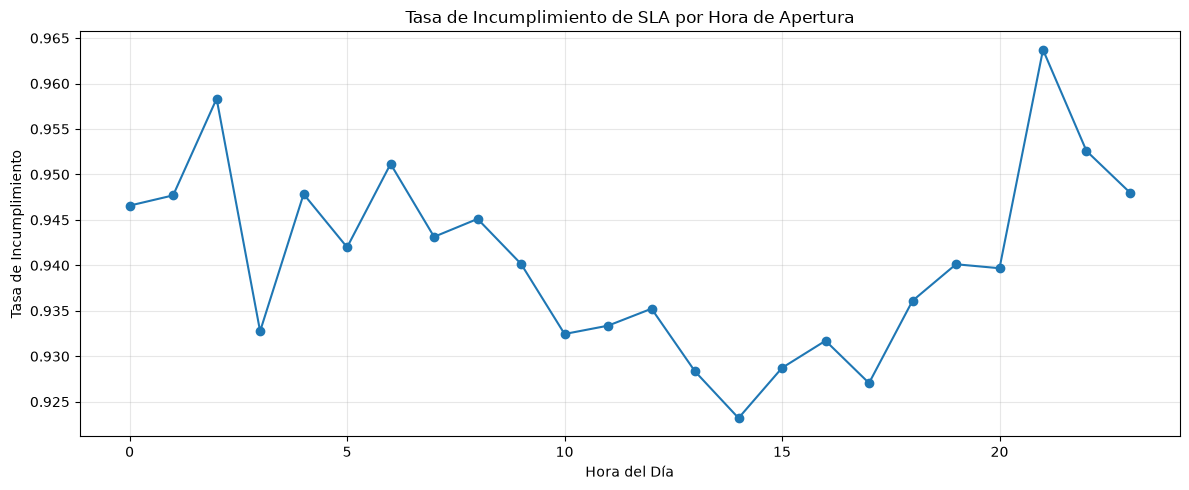

In [17]:
# Verificar que la columna open_hour exista en el DataFrame
if "open_hour" in df.columns:

    # Calcular tasa de incumplimiento promedio por hora de apertura
    sla_por_hora = df.groupby("open_hour")["made_sla_num"].mean()

    # Crear figura para el gráfico de líneas
    plt.figure(figsize=(12, 5))

    # Crear gráfico de líneas con marcadores circulares
    sla_por_hora.plot(kind="line", marker="o")

    # Establecer título
    plt.title("Tasa de Incumplimiento de SLA por Hora de Apertura")

    # Etiqueta del eje X
    plt.xlabel("Hora del Día")

    # Etiqueta del eje Y
    plt.ylabel("Tasa de Incumplimiento")

    # Activar cuadrícula con transparencia
    plt.grid(True, alpha=0.3)

    # Ajustar diseño
    plt.tight_layout()

    # Guardar figura
    plt.savefig(f"{ruta_graficos}/Nb03_10_incumplimiento_por_hora.png", dpi=300, bbox_inches="tight")

    # Mostrar gráfico
    plt.show()


##### Análisis: Incumplimiento de SLA por hora de apertura
La tasa de incumplimiento varía a lo largo del día, con picos en ciertas horas que podrían coincidir con cambios de turno, horas de mayor carga de trabajo, o tickets abiertos fuera del horario laboral. Este patrón temporal puede ser útil para ajustar la asignación de recursos según la hora del día.
